In [2]:
from google.colab import files
uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [3]:
import pandas as pd
df = pd.read_csv("HR_comma_sep.csv")

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print(df.head())

print(df.info())

print(df.isnull().sum())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

In [5]:
# Correlation matrix
corr = df.corr(numeric_only=True)
print(corr['left'].sort_values(ascending=False))

left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


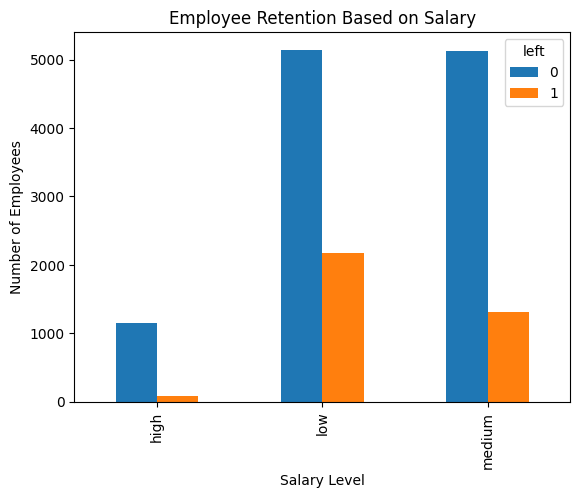

In [6]:
salary_retention = pd.crosstab(df['salary'], df['left'])

salary_retention.plot(kind='bar')
plt.title("Employee Retention Based on Salary")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

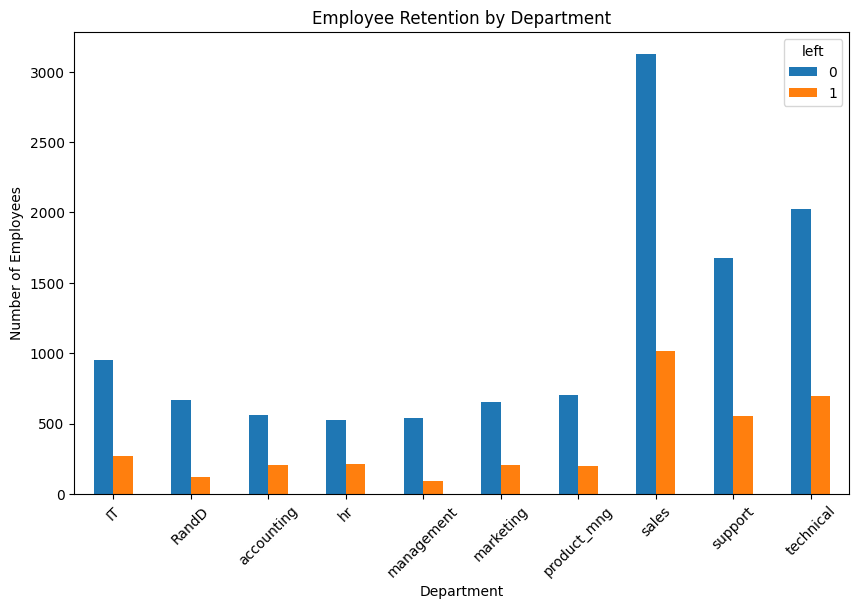

In [7]:
dept_retention = pd.crosstab(df['Department'], df['left'])

dept_retention.plot(kind='bar', figsize=(10,6))
plt.title("Employee Retention by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

In [8]:
# Select useful features
X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years',
        'time_spend_company']]

# Convert categorical variable salary into dummy variables
salary_dummies = pd.get_dummies(df['salary'], drop_first=True)

X = pd.concat([X, salary_dummies], axis=1)

# Target variable
y = df['left']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7566666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      2294
           1       0.47      0.24      0.32       706

    accuracy                           0.76      3000
   macro avg       0.63      0.58      0.58      3000
weighted avg       0.72      0.76      0.73      3000



In [21]:
from google.colab import files
uploaded = files.upload()

Saving zoo-class-type.csv to zoo-class-type (1).csv
Saving zoo-data.csv to zoo-data.csv


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
zoo = pd.read_csv('zoo-data.csv')

print(zoo.head())
print(zoo.dtypes)

  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2           4  
3   

In [35]:
zoo.drop('animal_name', axis=1, inplace=True)

In [36]:
print(zoo.dtypes)

hair          int64
feathers      int64
eggs          int64
milk          int64
airborne      int64
aquatic       int64
predator      int64
toothed       int64
backbone      int64
breathes      int64
venomous      int64
fins          int64
legs          int64
tail          int64
domestic      int64
catsize       int64
class_type    int64
dtype: object


In [37]:
X = zoo.drop('class_type', axis=1)
y = zoo['class_type']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

Accuracy: 0.9523809523809523

Classification Report:
              precision    recall  f1-score    support
1              1.000000  1.000000  1.000000  12.000000
2              1.000000  1.000000  1.000000   2.000000
3              0.000000  0.000000  0.000000   1.000000
4              0.666667  1.000000  0.800000   2.000000
6              1.000000  1.000000  1.000000   3.000000
7              1.000000  1.000000  1.000000   1.000000
accuracy       0.952381  0.952381  0.952381   0.952381
macro avg      0.777778  0.833333  0.800000  21.000000
weighted avg   0.920635  0.952381  0.933333  21.000000


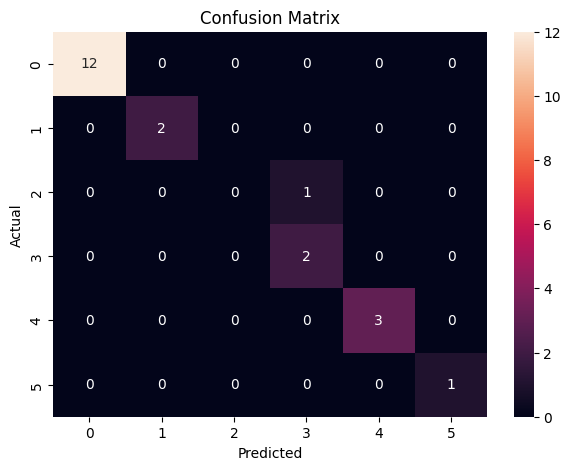

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()